# Extracting PM2.5 Concentrations at Defined Geographic Coordinates

This notebook shows, step by step, how to pull **daily PM2.5** values out of our
long-term dataset at arbitrary latitude/longitude locations.

**What you'll see**

1. **Step 1 — peek at the data:** read the CRS straight from a file and map a single day.
2. **Step 2 — validate & reproject** query coordinates.
3. **Step 3 — define the period** (a date range) to extract.
4. **Step 4 — the core extraction function.**
5. **Part 1 — single pixel:** a daily time series for one lat/lon.
6. **Part 2 — many points:** a dummy list of major CONUS cities, exported to CSV.

For large jobs, a companion script (`batch_extract_pm25.py`) does the same in bulk
— see the last section.

## Dataset layout & assumptions

The dataset is stored as **one NetCDF file per month**, and each file holds
**daily** slices:

```
<DATA_DIR>/dataset_<YEAR>/pm25_<YEAR>-<MM>.nc      e.g.  dataset_2005/pm25_2005-08.nc
```

Structure (from the real files):

| item | value |
|------|-------|
| variable | `PM2.5` |
| dims | `(date, y, x)` — `date` is daily `datetime64` |
| grid | projected, **CRS embedded in the file** (`EPSG:5070`, NAD83 / Conus Albers) |

Because the CRS travels with the data, we **read it from the file** (opening with
`decode_coords="all"`) rather than hard-coding a projection — and reproject query
points from EPSG:4326 into it before sampling.

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # noqa: F401  (registers the .rio accessor on xarray objects)
from pyproj import CRS, Transformer, network
network.set_network_enabled(False)

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Progress bar (falls back to a no-op if tqdm isn't installed).
try:
    from tqdm.auto import tqdm
except Exception:               # pragma: no cover
    def tqdm(iterable=None, *args, **kwargs):
        return iterable if iterable is not None else []

In [2]:
# --- Configuration ---------------------------------------------------------- #
DATA_DIR = "./"   # <-- point at the real dataset for production use
VAR_NAME = "PM2.5"         # NetCDF variable to sample
VAR_PREFIX = "pm25"        # filename prefix

# Approximate CONUS bounding box in lon/lat (padded). Extent sanity check only.
CONUS_BOUNDS = dict(lat_min=24.0, lat_max=50.0, lon_min=-125.0, lon_max=-66.5)


def month_file_path(year, month, data_dir=DATA_DIR):
    """e.g. ./demo_data/dataset_2005/pm25_2005-08.nc"""
    return os.path.join(data_dir, f"dataset_{year}", f"{VAR_PREFIX}_{year}-{month:02d}.nc")


def open_month(year, month, data_dir=DATA_DIR):
    """Open a monthly file with the embedded CRS decoded (decode_coords='all')."""
    return xr.open_dataset(month_file_path(year, month, data_dir), decode_coords="all")


print("Example path:", month_file_path(2005, 8))

Example path: ./dataset_2005/pm25_2005-08.nc


## Step 1 — Peek at the data & visualize a defined day

Open one monthly file, read its **embedded CRS** (no hard-coding), pick a date,
and map that day's PM2.5 field. We also overlay one query point (Boston),
reprojected into the data's CRS, to show how a lat/lon lands on the grid.

Dataset CRS : EPSG:5070
Variable    : PM2.5 | dims: ('date', 'y', 'x')
Date range  : 2005-08-25 -> 2005-08-31
Boulder projected coordinates: x=-783,090.8, y=1,926,882.3


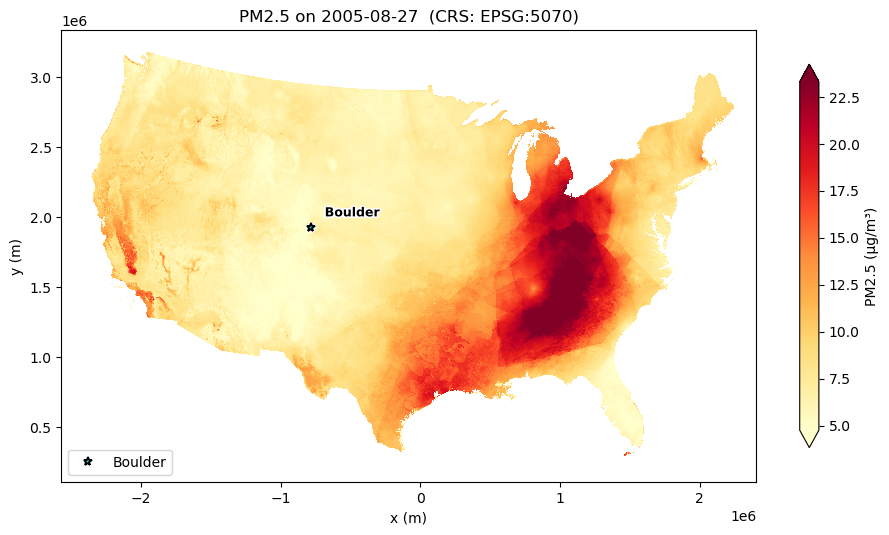

In [ ]:
# Read the CRS straight from the data.
ds0 = open_month(2005, 8)
DATA_CRS = ds0.rio.crs
print("Dataset CRS :", DATA_CRS)                 # -> EPSG:5070
print("Variable    :", VAR_NAME, "| dims:", ds0[VAR_NAME].dims)
print("Date range  :", str(ds0.date.values[0])[:10], "->", str(ds0.date.values[-1])[:10])

# Reproject a demo point of interest (EPSG:4326 -> data CRS).
src_crs = CRS.from_epsg(4326)
dst_crs = CRS.from_user_input(ds0.rio.crs)
transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
POI_NAME = "Boulder"
poi_lat, poi_lon = 40.014984, -105.270546
bx, by = transformer.transform(poi_lon, poi_lat, errcheck=True)
print(f"{POI_NAME} projected coordinates: x={bx:,.1f}, y={by:,.1f}")

VIEW_DATE = "2005-08-27"
day = ds0[VAR_NAME].sel(date=VIEW_DATE)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
day.plot.imshow(ax=ax, x="x", y="y", cmap="YlOrRd", robust=True,
                cbar_kwargs={"label": "PM2.5 (µg/m³)", "shrink": 0.8})

xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.set_aspect("equal")

ax.plot(bx, by, marker="*", markersize=6, linestyle="None",
        markerfacecolor="cyan", markeredgecolor="black", markeredgewidth=1.4,
        zorder=20, clip_on=False, label=POI_NAME,
        path_effects=[pe.withStroke(linewidth=3.5, foreground="white")])
ax.annotate(POI_NAME, (bx, by), xytext=(10, 8), textcoords="offset points",
            fontsize=9, fontweight="bold", zorder=21,
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title(f"{VAR_NAME} on {VIEW_DATE}  (CRS: {DATA_CRS})")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.legend(loc="lower left")
fig.tight_layout(); plt.show()
ds0.close()

## Step 2 — Validate & reproject coordinates

Two helpers:

* `within_conus(lat, lon)` — quick bounding-box check. (It's a box, so a `NaN`
  extraction later flags points outside the *actual* data coverage.)
* `lonlat_to_xy(lon, lat)` — reproject EPSG:4326 → the data CRS (read in Step 1).

In [4]:
def within_conus(lat, lon):
    return (CONUS_BOUNDS["lat_min"] <= lat <= CONUS_BOUNDS["lat_max"]
            and CONUS_BOUNDS["lon_min"] <= lon <= CONUS_BOUNDS["lon_max"])


def lonlat_to_xy(lon, lat):
    """Vectorized: scalars or arrays -> (x, y) in the data CRS (metres)."""
    return transformer.transform(lon, lat)


for name, (la, lo) in {"Boston": (42.3601, -71.0589),
                       "London": (51.5074, -0.1278)}.items():
    ok = within_conus(la, lo)
    print(f"{name:8s} valid={ok}", "->", lonlat_to_xy(lo, la) if ok else "(outside CONUS)")

Boston   valid=True -> (2017889.0129606186, 2417509.2765181065)
London   valid=False -> (outside CONUS)


## Step 3 — Define the period to extract

Choose a start and end **date** (inclusive). `months_spanned` lists the monthly
files that cover the range (the data is daily, one file per month).

In [5]:
def months_spanned(start, end):
    """Inclusive list of (year, month) covering the [start, end] date range."""
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    if e < s:
        raise ValueError(f"end ({end}) is before start ({start}).")
    periods = pd.period_range(s.to_period("M"), e.to_period("M"), freq="M")
    return [(p.year, p.month) for p in periods]


START, END = "2005-08-25", "2005-09-25"
MONTHS = months_spanned(START, END)
print(f"{START} -> {END} spans {len(MONTHS)} file(s):",
      [f"{y}-{m:02d}" for y, m in MONTHS])

2005-08-25 -> 2005-09-25 spans 2 file(s): ['2005-08', '2005-09']


## Step 4 — The core extraction function

`extract_timeseries` samples the variable at one or more points using xarray
point-wise **nearest** indexing (each `x` paired with its own `y`, so *N* points
give *N* series, not an *N*×*N* grid). It opens each month file once, keeps the
full daily `date` axis, concatenates across months, and clips to the requested
range. Returns a `(date, points)` DataArray.

Two behaviours worth noting:

* **Coastline / boundary NaNs.** Pixels dropped for only partially intersecting
  the CONUS polygon are `NaN`, so a coastal point's nearest pixel can be empty.
  With `fill_nearest_valid=True` (default), such a point is snapped to the
  **nearest pixel that actually has data**, up to `max_snap_km` (default 50 km);
  beyond that it stays `NaN`. Any snapped sites and their snap distance are
  reported. Pass `fill_nearest_valid=False` for strict nearest-pixel behaviour.
* **Progress bar.** A `tqdm` bar tracks progress across the monthly files.

In [6]:
def _sample_point_nearest_valid(da, xindex, yindex, dx, dy, px, py, max_radius_px):
    """Daily series at the nearest pixel to (px, py). If that pixel is NaN (e.g. a
    dropped coastline cell), snap to the nearest pixel that HAS data, searching
    outward up to max_radius_px. Returns (series, snap_distance_m)."""
    ix0 = int(np.abs(xindex - px).argmin())
    iy0 = int(np.abs(yindex - py).argmin())

    center = da.isel(y=iy0, x=ix0)
    if bool(center.notnull().all()):           # nearest pixel already has data
        return center, 0.0

    r = 1
    while r <= max_radius_px:                   # expand the search window
        y0, y1 = max(0, iy0 - r), min(da.sizes["y"], iy0 + r + 1)
        x0, x1 = max(0, ix0 - r), min(da.sizes["x"], ix0 + r + 1)
        if bool(da.isel(y=slice(y0, y1), x=slice(x0, x1)).notnull().all("date").any()):
            # widen once more so the Euclidean-nearest valid pixel is included
            R = int(np.ceil(r * 2 ** 0.5)) + 1
            y0, y1 = max(0, iy0 - R), min(da.sizes["y"], iy0 + R + 1)
            x0, x1 = max(0, ix0 - R), min(da.sizes["x"], ix0 + R + 1)
            win = da.isel(y=slice(y0, y1), x=slice(x0, x1))
            valid = win.notnull().all("date").values
            yy, xx = np.nonzero(valid)
            yy, xx = yy + y0, xx + x0
            dist = np.hypot((yy - iy0) * dy, (xx - ix0) * dx)
            k = int(np.argmin(dist))
            return da.isel(y=int(yy[k]), x=int(xx[k])), float(dist[k])
        r *= 2
    return center, np.nan                       # nothing valid within cap -> NaN


def extract_timeseries(xs, ys, site_ids, start, end,
                       var_name=VAR_NAME, data_dir=DATA_DIR,
                       fill_nearest_valid=True, max_snap_km=50.0, show_progress=True):
    xs = np.atleast_1d(np.asarray(xs, dtype=float))
    ys = np.atleast_1d(np.asarray(ys, dtype=float))
    site_ids = list(site_ids)

    months = months_spanned(start, end)
    pieces, snapped = [], {}
    iterator = tqdm(months, desc="Extracting", unit="file") if show_progress else months

    for (yy, mm) in iterator:
        path = month_file_path(yy, mm, data_dir)
        if not os.path.exists(path):
            print(f"[warn] missing file, skipping: {path}")
            continue
        with xr.open_dataset(path, decode_coords="all") as ds:
            da = ds[var_name]
            if not fill_nearest_valid:
                xi = xr.DataArray(xs, dims="points", coords={"points": site_ids})
                yi = xr.DataArray(ys, dims="points", coords={"points": site_ids})
                sampled = da.sel(x=xi, y=yi, method="nearest").load()
            else:
                xindex, yindex = da["x"].values, da["y"].values
                dx = abs(float(xindex[1] - xindex[0]))
                dy = abs(float(yindex[1] - yindex[0]))
                max_radius_px = int(np.ceil(max_snap_km * 1000 / min(dx, dy)))
                cols = []
                for pid, px, py in zip(site_ids, xs, ys):
                    s, dist = _sample_point_nearest_valid(
                        da, xindex, yindex, dx, dy, px, py, max_radius_px)
                    cols.append(s.load().reset_coords(drop=True))
                    if dist and not np.isnan(dist) and dist > 0:
                        snapped[pid] = max(snapped.get(pid, 0.0), dist)
                sampled = (xr.concat(cols, dim="points")
                           .assign_coords(points=site_ids)
                           .transpose("date", "points"))
            pieces.append(sampled)

    combined = (xr.concat(pieces, dim="date").sortby("date")
                .sel(date=slice(str(start), str(end))))
    if snapped:
        print("[info] snapped coastal point(s) to nearest valid pixel:",
              {k: f"{v/1000:.1f} km" for k, v in snapped.items()})
    return combined

## Part 1 — Extract a single pixel

Take one location (e.g., Boulder), validate it, reproject it, and pull its **daily**
value across the period to build a time series.

In [7]:
site_name = "Boulder"
site_lat, site_lon = 40.014984, -105.270546

assert within_conus(site_lat, site_lon), "Coordinate is outside the CONUS extent!"
sx, sy = lonlat_to_xy(site_lon, site_lat)
print(f"{site_name}: lat={site_lat}, lon={site_lon} -> x={sx:,.0f} m, y={sy:,.0f} m")

series = extract_timeseries([sx], [sy], [site_name], START, END).isel(points=0)
single_df = series.to_series().rename(VAR_NAME).reset_index()
single_df["date"] = single_df["date"].dt.strftime("%Y-%m-%d")
single_df.head()

Boulder: lat=40.014984, lon=-105.270546 -> x=-783,091 m, y=1,926,882 m


Extracting:   0%|          | 0/2 [00:00<?, ?file/s]

,date,PM2.5
0,2005-08-25,8.591314
1,2005-08-26,7.283714
2,2005-08-27,7.182825
3,2005-08-28,7.099552
4,2005-08-29,7.958928


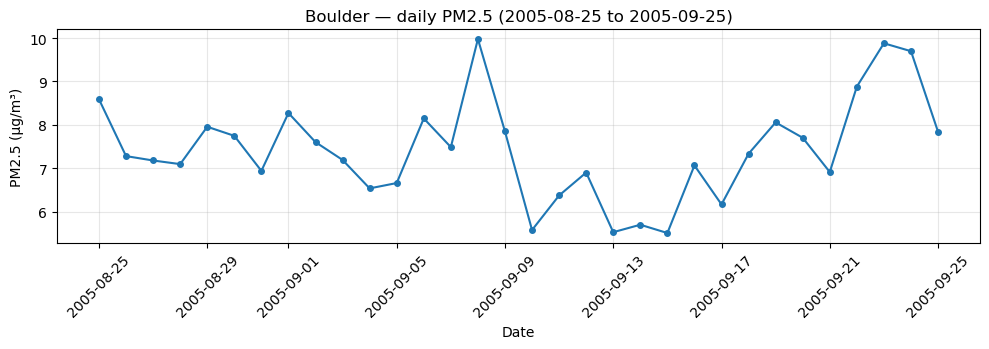

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(pd.to_datetime(single_df["date"]), single_df[VAR_NAME], marker="o", ms=4)
ax.set_title(f"{site_name} — daily {VAR_NAME} ({START} to {END})")
ax.set_ylabel("PM2.5 (µg/m³)"); ax.set_xlabel("Date")
ax.tick_params(axis="x", rotation=45); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## Part 2 — Extract a list of coordinates (major CONUS cities)

A dummy list of cities stands in for any coordinate table. We validate every
point, drop anything outside CONUS, extract all cities across the period in one
vectorized pass, and export a wide CSV (**site** rows × **date** columns).

In [9]:
cities = pd.DataFrame([
    ("New York",    40.7128,  -74.0060),
    ("Los Angeles", 34.0522, -118.2437),
    ("Chicago",     41.8781,  -87.6298),
    ("Houston",     29.7604,  -95.3698),
    ("Phoenix",     33.4484, -112.0740),
    ("Denver",      39.7392, -104.9903),
    ("Seattle",     47.6062, -122.3321),
    ("Atlanta",     33.7490,  -84.3880),
    ("Boston",      42.3601,  -71.0589),
    ("Miami",       25.7617,  -80.1918),
], columns=["city", "latitude", "longitude"])

cities["valid"] = [within_conus(la, lo)
                   for la, lo in zip(cities["latitude"], cities["longitude"])]
if (~cities["valid"]).any():
    print("Dropping out-of-extent:", cities.loc[~cities["valid"], "city"].tolist())
cities = cities[cities["valid"]].drop(columns="valid").reset_index(drop=True)

cities["x"], cities["y"] = lonlat_to_xy(cities["longitude"].values,
                                        cities["latitude"].values)
cities

,city,latitude,longitude,x,y
0,New York,40.7128,-74.0060,1.826304e+06,2.179112e+06
1,Los Angeles,34.0522,-118.2437,-2.019685e+06,1.458262e+06
2,Chicago,41.8781,-87.6298,6.888945e+05,2.127633e+06
3,Houston,29.7604,-95.3698,6.091624e+04,7.429951e+05
4,Phoenix,33.4484,-112.0740,-1.477243e+06,1.278583e+06
5,Denver,39.7392,-104.9903,-7.624090e+05,1.893844e+06
6,Seattle,47.6062,-122.3321,-1.967991e+06,3.009111e+06
7,Atlanta,33.7490,-84.3880,1.065520e+06,1.252108e+06
8,Boston,42.3601,-71.0589,2.017889e+06,2.417509e+06
9,Miami,25.7617,-80.1918,1.594077e+06,4.344700e+05


In [10]:
combined = extract_timeseries(cities["x"].values, cities["y"].values,
                              cities["city"].tolist(), START, END)

# (points, date) -> DataFrame index=city, columns=date -> wide site x date table
vals = combined.transpose("points", "date").to_pandas()
vals.columns = pd.DatetimeIndex(vals.columns).strftime("%Y-%m-%d")
vals = vals.reindex(cities["city"].values)

wide = cities[["city", "latitude", "longitude"]].copy()
for c in vals.columns:
    wide[c] = vals[c].values

export_path = "pm25_cities_extracted.csv"
wide.to_csv(export_path, index=False)
print("Wrote", export_path, "->", wide.shape[0], "sites x", len(vals.columns), "dates")
wide.iloc[:, :7]

Extracting:   0%|          | 0/2 [00:00<?, ?file/s]

[info] snapped coastal point(s) to nearest valid pixel: {'New York': '2.5 km', 'Miami': '1.2 km'}
Wrote pm25_cities_extracted.csv -> 10 sites x 32 dates


,city,latitude,longitude,2005-08-25,2005-08-26,2005-08-27,2005-08-28
0,New York,40.7128,-74.0060,7.462825,12.648534,7.911982,6.703429
1,Los Angeles,34.0522,-118.2437,18.619293,16.544758,15.921825,14.914189
2,Chicago,41.8781,-87.6298,16.341278,31.858467,16.609434,11.590426
3,Houston,29.7604,-95.3698,14.247513,18.564081,19.592819,18.522537
4,Phoenix,33.4484,-112.0740,8.829494,8.175799,8.667924,8.483254
5,Denver,39.7392,-104.9903,8.508819,7.507593,7.508501,7.401006
6,Seattle,47.6062,-122.3321,10.826511,11.177341,6.951890,3.706953
7,Atlanta,33.7490,-84.3880,28.357466,26.726593,22.073408,19.793386
8,Boston,42.3601,-71.0589,9.499313,10.943378,16.457268,9.112522
9,Miami,25.7617,-80.1918,3.200152,3.724496,5.041174,4.649038


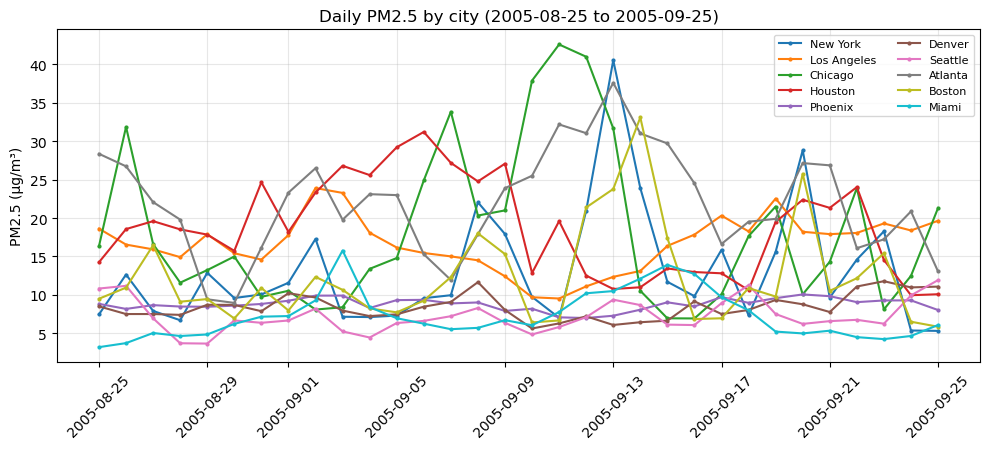

In [11]:
date_index = pd.to_datetime(vals.columns)
fig, ax = plt.subplots(figsize=(10, 4.6))
for city in cities["city"]:
    ax.plot(date_index, vals.loc[city].values, marker=".", ms=4, label=city)
ax.set_title(f"Daily {VAR_NAME} by city ({START} to {END})")
ax.set_ylabel("PM2.5 (µg/m³)"); ax.tick_params(axis="x", rotation=45)
ax.legend(ncol=2, fontsize=8, loc="upper right"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## Batch extraction from the command line

For large coordinate lists or long periods, use **`batch_extract_pm25.py`**
instead of this notebook. It takes a coordinates CSV and a date range and writes
a wide or long CSV. The CRS is read from the data automatically.

```bash
python batch_extract_pm25.py \
    --coords sample_coords.csv \
    --start 2005-08-25 --end 2005-09-25 \
    --data-dir ./demo_data \
    --var "PM2.5" \
    --output pm25_extracted.csv \
    --format wide
```

Useful options: `--data-dir` (base folder holding `dataset_<YEAR>/`), `--var`,
`--lat-col` / `--lon-col` / `--id-col` (your CSV's column names),
`--format wide|long`, `--keep-invalid` (keep out-of-CONUS points as `NaN`), and
`--crs` (override the auto-detected CRS if ever needed). Run
`python batch_extract_pm25.py --help` for the full list.